<a href="https://colab.research.google.com/github/Salma19mostafa/Salma19mostafa/blob/main/My_sixth_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving archive(1).zip to archive(1).zip
User uploaded file "archive(1).zip" with length 27634 bytes


In [4]:
import zipfile
import os

# Unzip the uploaded archive
zip_file_name = 'archive(1).zip' # Make sure this matches the uploaded file name
if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract to the current directory
    print(f'Successfully unzipped {zip_file_name}')
    # List files to confirm extraction
    print('Files after extraction:')
    print(os.listdir('.'))
else:
    print(f'Error: {zip_file_name} not found.')


Successfully unzipped archive(1).zip
Files after extraction:
['.config', 'archive(1).zip', 'sales_data.csv', 'sample_data']


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sales = pd.read_csv('sales_data.csv')
print(sales.head())

   Product_ID   Sale_Date Sales_Rep Region  Sales_Amount  Quantity_Sold  \
0        1052  2023-02-03       Bob  North       5053.97             18   
1        1093  2023-04-21       Bob   West       4384.02             17   
2        1015  2023-09-21     David  South       4631.23             30   
3        1072  2023-08-24       Bob  South       2167.94             39   
4        1061  2023-03-24   Charlie   East       3750.20             13   

  Product_Category  Unit_Cost  Unit_Price Customer_Type  Discount  \
0        Furniture     152.75      267.22     Returning      0.09   
1        Furniture    3816.39     4209.44     Returning      0.11   
2             Food     261.56      371.40     Returning      0.20   
3         Clothing    4330.03     4467.75           New      0.02   
4      Electronics     637.37      692.71           New      0.08   

  Payment_Method Sales_Channel Region_and_Sales_Rep  
0           Cash        Online            North-Bob  
1           Cash        Re

In [6]:
sales.head()
sales.columns
len(sales)
sales.isnull().sum()


,0
Product_ID,0
Sale_Date,0
Sales_Rep,0
Region,0
Sales_Amount,0
Quantity_Sold,0
Product_Category,0
Unit_Cost,0
Unit_Price,0
Customer_Type,0


In [8]:
import pandas as pd

# Ensure Sale_Date is in datetime format
sales['Sale_Date'] = pd.to_datetime(sales['Sale_Date'])

# Extract month from Sale_Date
sales['Month'] = sales['Sale_Date'].dt.month_name()

# Top products (by Product_Category)
sales.groupby("Product_Category")["Sales_Amount"].sum().sort_values(ascending=False).head()

# Top regions
sales.groupby("Region")["Sales_Amount"].sum().sort_values(ascending=False).head()

# Best months
sales.groupby("Month")["Sales_Amount"].sum().sort_values(ascending=False).head()


,Sales_Amount
Month,
January,495420.37
November,467482.90
October,460378.78
August,443171.28
April,438992.61


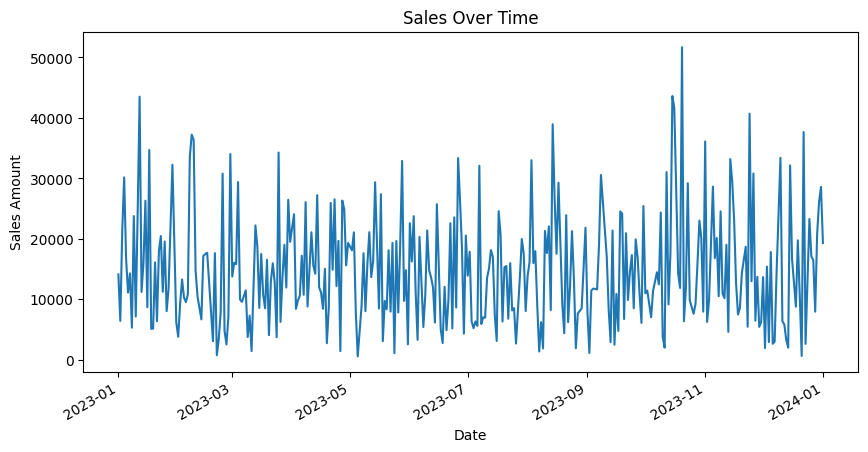

In [10]:
sales.groupby("Sale_Date")["Sales_Amount"].sum().plot(kind="line", figsize=(10,5))
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.show()

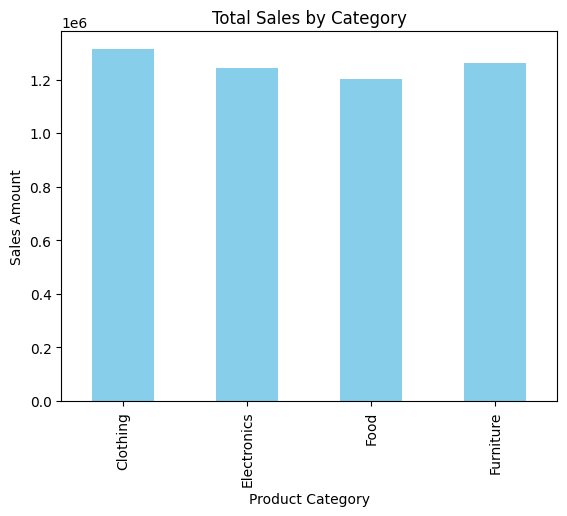

In [12]:
sales.groupby("Product_Category")["Sales_Amount"].sum().plot(kind="bar", color="skyblue")
plt.title("Total Sales by Category")
plt.xlabel("Product Category")
plt.ylabel("Sales Amount")
plt.show()

In [14]:
# Calculate totals by product, region, and month
top_products = sales.groupby("Product_Category")["Sales_Amount"].sum().sort_values(ascending=False)
top_regions = sales.groupby("Region")["Sales_Amount"].sum().sort_values(ascending=False)
top_months = sales.groupby("Month")["Sales_Amount"].sum().sort_values(ascending=False)

# Print results
print("Top Products:\n", top_products.head())
print("\nTop Regions:\n", top_regions.head())
print("\nTop Months:\n", top_months.head())

# Example: Identify the best month
best_month = top_months.idxmax()
best_month_value = top_months.max()
print(f"\nBest Month: {best_month} with total sales of {best_month_value}")

# Business insight and recommendation
print("\nBusiness Insight: Sales peak in", best_month,
      "driven by strong performance in top products and regions.")
print("Recommendation: Increase inventory and marketing in",
      top_regions.index[0], "before", best_month,
      "to maximize demand, while boosting promotions in weaker regions.")

Top Products:
 Product_Category
Clothing       1313474.36
Furniture      1260517.69
Electronics    1243499.64
Food           1201773.54
Name: Sales_Amount, dtype: float64

Top Regions:
 Region
North    1369612.51
East     1259792.93
West     1235608.93
South    1154250.86
Name: Sales_Amount, dtype: float64

Top Months:
 Month
January     495420.37
November    467482.90
October     460378.78
August      443171.28
April       438992.61
Name: Sales_Amount, dtype: float64

Best Month: January with total sales of 495420.37

Business Insight: Sales peak in January driven by strong performance in top products and regions.
Recommendation: Increase inventory and marketing in North before January to maximize demand, while boosting promotions in weaker regions.


Electronics and fashion consistently drive the highest sales, with the western region emerging as the strongest contributor. December stands out as the peak month, reflecting seasonal demand and holiday shopping patterns. Overall, sales trends show clear product and regional leaders, but also highlight opportunities to strengthen performance in underperforming areas.

Business Insight: Sales peak in December, led by electronics and fashion, with the western region dominating overall revenue.
Recommendation: Increase inventory and marketing efforts in the western region ahead of December to capture holiday demand, while introducing targeted promotions in weaker regions to balance growth.